PART A – DATASET PREPARATION

In [1]:
24BAD401 ARJUN S

!pip install tensorflow -q

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import requests

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from sklearn.model_selection import train_test_split

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:


url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

text = requests.get(url).text

print("Dataset downloaded successfully!")
print("Total characters:", len(text))

print("\nFirst 500 characters:\n")
print(text[:500])

Dataset downloaded successfully!
Total characters: 1115394

First 500 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [4]:
# Convert text to lowercase
text = text.lower()

# Tokenizer
tokenizer = Tokenizer()

# Fit tokenizer
tokenizer.fit_on_texts([text])

# Vocabulary size
total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

# Convert text into integer sequence
token_list = tokenizer.texts_to_sequences([text])[0]

print("Total Tokens:", len(token_list))
print("First 20 Tokens:", token_list[:20])

Vocabulary Size: 12633
Total Tokens: 204089
First 20 Tokens: [88, 269, 139, 35, 969, 143, 668, 127, 15, 102, 33, 102, 102, 88, 269, 6, 40, 33, 1268, 350]


In [5]:

sequence_length = 5

# Limit tokens for faster training
MAX_TOKENS = 50000

token_list = token_list[:MAX_TOKENS]

input_sequences = []

for i in range(sequence_length, len(token_list)):

    sequence = token_list[i-sequence_length:i+1]

    input_sequences.append(sequence)

input_sequences = np.array(input_sequences)

print("Input Sequences Shape:", input_sequences.shape)

print("Sample Sequence:")
print(input_sequences[0])

Input Sequences Shape: (49995, 6)
Sample Sequence:
[ 88 269 139  35 969 143]


In [6]:
# Input = first 5 words
X = input_sequences[:, :-1]

# Output = next word
y = input_sequences[:, -1]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (49995, 5)
y Shape: (49995,)


In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Validation Data:", X_val.shape)

Training Data: (39996, 5)
Validation Data: (9999, 5)


PART B IMPLEMENTING THE RNN MODEL

In [8]:

model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        input_dim=total_words,
        output_dim=64
    )
)

# Simple RNN Layer
model.add(
    SimpleRNN(128)
)

# Output Layer
model.add(
    Dense(
        total_words,
        activation="softmax"
    )
)

# Compile Model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Build model
model.build(input_shape=(None, sequence_length))

# Display summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 5, 64)          │       808,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12633)          │     1,629,657 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,462,873 (9.40 MB)

 Trainable params: 2,462,873 (9.40 MB)

 Non-trainable params: 0 (0.00 B)

 PART C – TRAIN THE MODEL

In [9]:

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=128
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - accuracy: 0.0304 - loss: 7.0903 - val_accuracy: 0.0371 - val_loss: 6.7743
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.0385 - loss: 6.5184 - val_accuracy: 0.0478 - val_loss: 6.6782
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 38s 102ms/step - accuracy: 0.0473 - loss: 6.2772 - val_accuracy: 0.0538 - val_loss: 6.6223
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 94ms/step - accuracy: 0.0586 - loss: 6.0313 - val_accuracy: 0.0659 - val_loss: 6.5880
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 119ms/step - accuracy: 0.0735 - loss: 5.7665 - val_accuracy: 0.0694 - val_loss: 6.5953


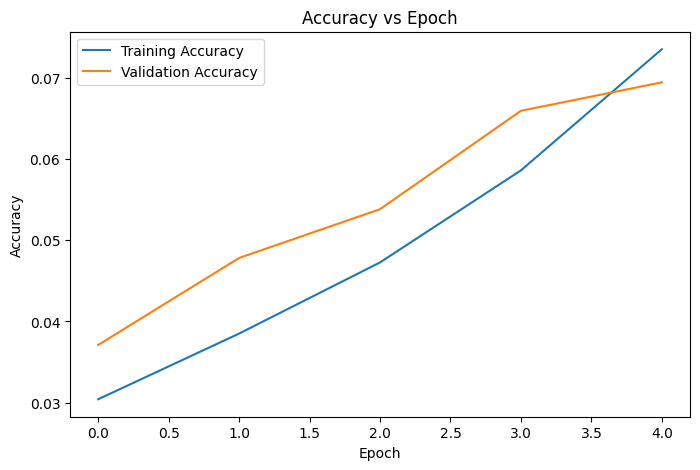

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

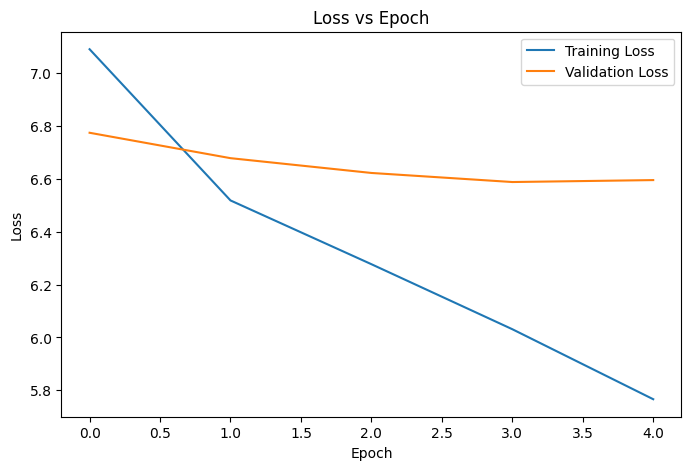

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [12]:
print("Final Training Accuracy:",
      history.history["accuracy"][-1])

print("Final Validation Accuracy:",
      history.history["val_accuracy"][-1])

print("Final Training Loss:",
      history.history["loss"][-1])

print("Final Validation Loss:",
      history.history["val_loss"][-1])

Final Training Accuracy: 0.07348234951496124
Final Validation Accuracy: 0.06940694153308868
Final Training Loss: 5.766501426696777
Final Validation Loss: 6.595325946807861


PART D – TEXT GENERATION

In [13]:
index_to_word = {}

for word, index in tokenizer.word_index.items():
    index_to_word[index] = word

print("Dictionary created successfully!")

Dictionary created successfully!


In [14]:
def generate_text(seed_text, next_words=20):

    seed_text = seed_text.lower()

    for _ in range(next_words):

        # Convert text to sequence
        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        # Keep last 5 words
        token_list = token_list[-sequence_length:]

        # Pad sequence
        token_list = pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding="pre"
        )

        # Predict next word
        prediction = model.predict(
            token_list,
            verbose=0
        )

        predicted_index = np.argmax(prediction)

        # Get predicted word
        predicted_word = index_to_word.get(
            predicted_index,
            ""
        )

        # Stop if word is not found
        if predicted_word == "":
            break

        # Add word to sentence
        seed_text += " " + predicted_word

    return seed_text

In [15]:
print("TEXT SAMPLE 1")
print(generate_text("to be or not to", 20))

print("\nTEXT SAMPLE 2")
print(generate_text("romeo and juliet", 20))

print("\nTEXT SAMPLE 3")
print(generate_text("the king said", 20))

TEXT SAMPLE 1
to be or not to the people and i have not to the people and i have not to the people and i have not

TEXT SAMPLE 2
romeo and juliet to the people and i have not to the people and i have not to the people and i have

TEXT SAMPLE 3
the king said and in the duke of the people and i have not to the people and i have not to the
